# Spacecraft Rendezvous Control Project
### Q3: Optimal Rendezvous and Docking
**Author:** Teeramet Sahastharchai  
**Date:** March 2026

---

## Table of Contents
 
1. [Environment Setup and Libraries](#1-environment-setup-and-libraries)
2. [Vector Utilities and Dynamics](##2-vector-utilities-and-dynamics)
3. [Finite Horizon LQR](#3-finite-horizon-lqr)
4. [State Estimate](#4-state-estimate)
5. [Thruster Model](#5-thruster-model)
6. [Convex Trajectory Optimization](#6-convex-trajectory-optimization)
7. [Convex MPC](#7-convex-mpc)
8. [Main Simulations](#8-main-simulations)
9. [LQR Simulation](#9-lqr-simulation)
10. [Convex Trajectory Optimization Simulation](#10-convex-trajectory-optimization-simulation)
11. [Convex MPC Simulation](#11-convex-mpc-simulation)
12. [Noise and Disturbance Analysis](#12-noise-and-disturbance-analysis)
13. [Fuel Consumption Comparison](#13-fuel-consumption-comparison)

---

## Overview

This notebook develops and analyzes control strategies for spacecraft rendezvous using the **Clohessy-Wiltshire (CW)** linear dynamics model. The goal is to control the SpaceX Dragon spacecraft as it docks with the International Space Station (ISS).



In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cvx
import meshcat as mc
import meshcat.geometry as geom
import meshcat.transformations as tf
from autograd import grad, jacobian
from tqdm import tqdm
import importlib
import rendezvous
from IPython.display import IFrame, display
importlib.reload(rendezvous)
from scipy.linalg import expm

## 2. Vector Utilities and Dynamics
 
### Vector Utilities
 
Two helper functions handle conversion between data formats used throughout the project. `mat_from_vec` stacks a list of vectors into a matrix column-wise, while `vec_from_mat` does the reverse. These are needed because the simulation and control loops work with lists of vectors, while plotting and optimization routines expect matrix form.
 
### Discrete-Time Orbital Dynamics
 
The spacecraft dynamics follow the Clohessy-Wiltshire equations, a linearized model of relative orbital motion. The state vector is $x = [r_x, r_y, r_z, v_x, v_y, v_z]^T$ where $r$ is the relative position and $v$ is the relative velocity of Dragon with respect to the ISS.
 
The continuous-time system $\dot{x} = Ax + Bu$ is discretized using the matrix exponential by constructing an augmented matrix from $A$ and $B$, then computing $e^{M \cdot dt}$. This gives an exact discrete-time model $x_{k+1} = A_d x_k + B_d u_k$ with no numerical approximation error, which is important for the accuracy of the subsequent optimization problems.
 
The gravitational parameter is $\mu = 3.986 \times 10^{14}$ m$^3$/s$^2$, the orbital radius is $a = 6{,}971{,}100$ m, and the mean motion $n = \sqrt{\mu/a^3}$ defines the natural frequency of the relative orbital motion.

In [4]:
# =========================
# VECTOR UTILITIES
# =========================
def mat_from_vec(X):
    return np.column_stack(X)

def vec_from_mat(Xm):
    return [Xm[:, i] for i in range(Xm.shape[1])]

# =========================
# DYNAMICS
# =========================
def create_dynamics(dt):
    mu = 3.986004418e14
    a = 6971100.0
    n = np.sqrt(mu / a**3)

    A = np.array([
        [0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 1],
        [3*n*n, 0, 0, 0, 2*n, 0],
        [0, 0, 0, -2*n, 0, 0],
        [0, 0, -n*n, 0, 0, 0]
    ], dtype=float)

    B = np.zeros((6, 3))
    B[3:, :] = 0.1 * np.eye(3)

    M = np.zeros((9, 9))
    M[0:6, 0:6] = A
    M[0:6, 6:9] = B
    expM = expm(M * dt)
    Ad = expM[0:6, 0:6]
    Bd = expM[0:6, 6:9]

    return Ad, Bd

## 3. Finite Horizon LQR
 
The `fhlqr` function computes optimal feedback gains for a discrete-time linear system over a finite horizon by solving the discrete Riccati equation **backwards in time**.
 
The objective is to minimize the quadratic cost:
 
$$J = \sum_{k=0}^{N-1} \left( x_k^T Q x_k + u_k^T R u_k \right) + x_N^T Q_f x_N$$
 
where $Q$ penalizes state deviation, $R$ penalizes control effort, and $Q_f$ enforces terminal accuracy.
 
The recursion is initialized with $P_{N-1} = Q_f$ and proceeds backwards, computing at each step the optimal feedback gain:
 
$$K_k = (R + B^T P_{k+1} B)^{-1} B^T P_{k+1} A$$
 
and the cost-to-go update:
 
$$P_k = Q + K_k^T R K_k + (A - BK_k)^T P_{k+1} (A - BK_k)$$
 
The resulting control law is $u_k = -K_k (x_k - x_{ref,k})$, which drives the system towards the reference trajectory. The gains are time-varying over the horizon, computed offline before simulation begins.

In [5]:
# =========================
# FHLQR
# =========================
def fhlqr(A, B, Q, R, Qf, N):
    nx, nu = B.shape
    assert A.shape == (nx, nx)
    assert Q.shape == (nx, nx)
    assert R.shape == (nu, nu)
    assert Qf.shape == (nx, nx)

    P = [np.zeros((nx, nx)) for _ in range(N)]
    K = [np.zeros((nu, nx)) for _ in range(N-1)]
    P[N-1] = Qf.copy()

    for k in range(N-2, -1, -1):
        K[k] = np.linalg.solve(
            R + B.T @ P[k+1] @ B,
            B.T @ P[k+1] @ A
        )
        P[k] = (
            Q
            + K[k].T @ R @ K[k]
            + (A - B @ K[k]).T @ P[k+1] @ (A - B @ K[k])
        )

    return P, K

## 4. State Estimate
 
The `state_estimate` function simulates imperfect sensing by adding Gaussian noise to the true state. This models real-world sensor uncertainty where position and velocity measurements are never perfectly accurate.
 
Gaussian noise is added independently to the position and velocity components with standard deviations $\sigma_p = 0.01$ m and $\sigma_v = 0.0001$ m/s respectively. When the spacecraft is within 1 meter of the goal, noise is disabled to allow clean final docking without sensor interference.
 
This function is used in the MPC loop to simulate the sim-to-real gap — the controller never sees the true state, only a noisy estimate of it.

In [6]:
# =========================
# STATE ESTIMATE (with noise)
# matches Julia state_estimate()
# =========================
def state_estimate(x, xg):
    sigma_p = 0.01    # position noise
    sigma_v = 0.0001  # velocity noise

    # disable noise near goal
    if np.linalg.norm(x - xg) < 1.0:
        return x.copy()

    noise = np.concatenate([
        np.random.randn(3) * sigma_p,
        np.random.randn(3) * sigma_v
    ])
    return x + noise

## 5. Thruster Model
 
The `thruster_model` function simulates real-world actuator imperfections by distorting the commanded control input before it is applied to the system. Two sources of error are modeled.
 
The first is **thruster misalignment**, where the actual thrust direction differs slightly from the commanded direction. A Direction Cosine Matrix (DCM) is constructed from a small rotation vector $\phi$ using Rodrigues' formula:
 
$$Q = I + \sin(\theta)[r]_\times + (1 - \cos(\theta))[r]_\times^2$$
 
where $\theta = \|\phi\|$ is the rotation angle and $[r]_\times$ is the skew-symmetric matrix of the unit rotation axis.
 
The second is **thrust scaling imperfection**, where each thruster produces a slightly different force than commanded. This is represented by a diagonal scaling matrix $S = \text{diag}(0.95, 1.03, 1.01)$, meaning the x-thruster produces 5% less thrust, while y and z produce 3% and 1% more respectively.
 
The actual applied control is therefore $u_{actual} = M S \, u_{commanded}$. Like the state estimate, disturbances are disabled within 1 meter of the goal to allow clean final docking. Together with sensor noise, this thruster model creates the sim-to-real gap that MPC is designed to handle.

In [7]:
# =========================
# THRUSTER MODEL (with imperfections)
# matches Julia thruster_model()
# =========================
def dcm_from_phi(phi):
    theta = np.linalg.norm(phi)
    if theta < 1e-10:
        return np.eye(3)
    r = phi / theta
    rx = np.array([
        [0,    -r[2],  r[1]],
        [r[2],  0,    -r[0]],
        [-r[1], r[0],  0   ]
    ])
    return np.eye(3) + np.sin(theta) * rx + (1 - np.cos(theta)) * rx @ rx

def thruster_model(x, xg, u):
    # disable disturbances near goal
    if np.linalg.norm(x - xg) < 1.0:
        return u.copy()

    # misalignment rotation
    phi = np.array([0.01, -0.01, 0.005])
    M = dcm_from_phi(phi)

    # scaling imperfections
    S = np.diag([0.95, 1.03, 1.01])

    return M @ S @ u

## 6. Convex Trajectory Optimization
 
The `convex_trajopt` function formulates the rendezvous problem as a finite-horizon constrained convex optimization, solving for the entire state and control trajectory at once using CVXPY with the ECOS solver.
 
The objective minimizes a quadratic cost over tracking error and control effort:
 
$$J = \sum_{k=0}^{N-1} \frac{1}{2}(x_k - x_{ref,k})^T Q (x_k - x_{ref,k}) + \sum_{k=0}^{N-2} \frac{1}{2} u_k^T R u_k$$
 
where $Q = I$ and $R = I$.
 
The following constraints are enforced simultaneously:
 
- **Initial condition**: $x_0 = x_{init}$
- **Terminal condition**: $x_{N-1} = x_{goal}$
- **Dynamics**: $x_{k+1} = A x_k + B u_k$ for all $k$
- **ISS docking constraint**: $y_k \leq y_{goal}$ for all $k$, ensuring the spacecraft approaches from the correct corridor and never passes through the ISS
- **Control bounds**: $u_{min} \leq u_k \leq u_{max}$ for all $k$
 
Because the cost is quadratic and all constraints are linear, the problem is convex and guaranteed to find the global optimum. Unlike LQR, constraints are handled exactly rather than through clipping. However, this is an open-loop method — the trajectory is solved once offline and executed without feedback, meaning any disturbance or model mismatch will cause the spacecraft to drift from the planned path.
 

In [ ]:
# =========================
# CONVEX TRAJECTORY OPTIMIZATION
# matches Julia convex_trajopt() - N=100, desired_trajectory
# =========================
def convex_trajopt(A, B, X_ref, x0, xg, u_min, u_max, N):
    nx, nu = B.shape
    assert A.shape == (nx, nx)
    assert len(x0) == nx
    assert len(xg) == nx

    Q = np.eye(nx)
    R = np.eye(nu)

    X = cvx.Variable((nx, N))
    U = cvx.Variable((nu, N-1))

    obj = 0
    for i in range(N):
        obj += 0.5 * cvx.quad_form(X[:, i] - X_ref[i], Q)
    for i in range(N-1):
        obj += 0.5 * cvx.quad_form(U[:, i], R)

    objective = cvx.Minimize(obj)

    constraints = []
    constraints.append(X[:, 0] == x0)
    constraints.append(X[:, N-1] == xg)

    for i in range(N-1):
        constraints.append(X[:, i+1] == A @ X[:, i] + B @ U[:, i])

    for i in range(N):
        constraints.append(X[1, i] <= xg[1])

    for i in range(N-1):
        constraints.append(U[:, i] <= u_max)
        constraints.append(U[:, i] >= u_min)

    prob = cvx.Problem(objective, constraints)
    prob.solve(solver=cvx.ECOS, verbose=False)

    Xcvx = [X.value[:, i] for i in range(N)]
    Ucvx = [U.value[:, i] for i in range(N-1)]

    return Xcvx, Ucvx

## 7. Convex MPC
 
The `convex_mpc` function implements Model Predictive Control by solving a convex optimization problem at every timestep over a sliding window of size $N_{mpc}$. Unlike the full trajectory optimization, only the first control input from the solution is returned and applied, then the problem is re-solved at the next step with the updated state.
 
The optimization problem is identical in structure to the convex trajectory optimization but with two key differences. First, the horizon is short — only $N_{mpc} = 20$ steps ahead rather than the full trajectory. Second, there is no terminal equality constraint forcing $x_{N_{mpc}} = x_{goal}$, allowing the optimizer more flexibility within each window.
 
At each timestep $i$, the current noisy state estimate is used as the initial condition $x_{IC}$, and the reference window is sliced as $\tilde{x}_{ref} = X_{ref}[i : i + N_{mpc}]$. This gives MPC its feedback character — by re-solving with the actual current state at every step, the controller continuously corrects for any drift caused by sensor noise or thruster imperfections.
 
The combination of feedback correction and explicit constraint enforcement makes MPC the most robust of the three methods. It handles the sim-to-real gap that causes both LQR and convex trajectory optimization to degrade under realistic conditions.

In [ ]:
# =========================
# CONVEX MPC
# matches Julia convex_mpc()
# =========================
def convex_mpc(A, B, X_ref_window, xic, xg, u_min, u_max, N_mpc):
    nx, nu = B.shape
    assert A.shape == (nx, nx)
    assert len(xic) == nx
    assert len(xg) == nx
    assert len(X_ref_window) == N_mpc

    Q = np.eye(nx)
    R = np.eye(nu)

    X = cvx.Variable((nx, N_mpc))
    U = cvx.Variable((nu, N_mpc-1))

    obj = 0
    for i in range(N_mpc):
        obj += 0.5 * cvx.quad_form(X[:, i] - X_ref_window[i], Q)
    for i in range(N_mpc-1):
        obj += 0.5 * cvx.quad_form(U[:, i], R)

    constraints = []
    constraints.append(X[:, 0] == xic)

    for i in range(N_mpc-1):
        constraints.append(X[:, i+1] == A @ X[:, i] + B @ U[:, i])

    for i in range(N_mpc):
        constraints.append(X[1, i] <= xg[1])

    for i in range(N_mpc-1):
        constraints.append(U[:, i] <= u_max)
        constraints.append(U[:, i] >= u_min)

    prob = cvx.Problem(cvx.Minimize(obj), constraints)
    prob.solve(solver=cvx.ECOS, verbose=False)

    return U.value[:, 0]

## 8. Main Simulations
 
This section sets up the shared parameters used across all three control methods.
 
The time step is $dt = 1.0$ second, and the discrete dynamics matrices $A_d$ and $B_d$ are generated from `create_dynamics`. The spacecraft starts at $x_0 = [-2, -4, 2, 0, 0, 0]^T$ meters and must dock at $x_g = [0, -0.68, 3.05, 0, 0, 0]^T$. Control inputs are bounded by $u_{max} = 0.4$ N and $u_{min} = -0.4$ N in all three thrust directions, representing the physical saturation limits of the Dragon thrusters.

In [28]:
# =========================
# MAIN SIMULATIONS
# =========================

dt = 1.0
A, B = create_dynamics(dt)
nx, nu = B.shape

x0 = np.array([-2, -4, 2, 0, 0, 0.0])
xg = np.array([0, -0.68, 3.05, 0, 0, 0])
u_max = 0.4 * np.ones(3)
u_min = -u_max

## 9. LQR Simulation
 
The LQR controller runs over a horizon of $N = 120$ steps using a reference trajectory generated by `desired_trajectory_long`, which produces a circular docking approach followed by a hold at the goal state.
 
The cost matrices are set to $Q = I$, $R = I$, and $Q_f = 10I$, giving equal weight to state and control effort while enforcing stronger convergence at the terminal state. The feedback gains are computed offline via `fhlqr` before the simulation loop begins.
 
At each timestep the control law $u_k = -K_k(x_k - x_{ref,k})$ is applied and clipped to the actuator bounds. Since LQR has no built-in constraint handling, the clipping is the only mechanism preventing control saturation from being violated.
 
Position, velocity, and thrust are plotted over time to visualize the trajectory and control effort.
 

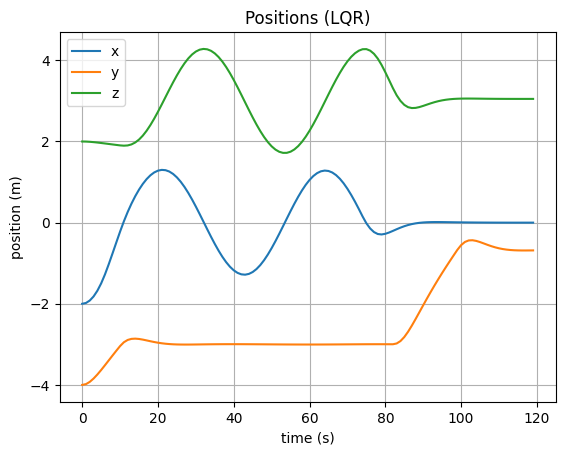

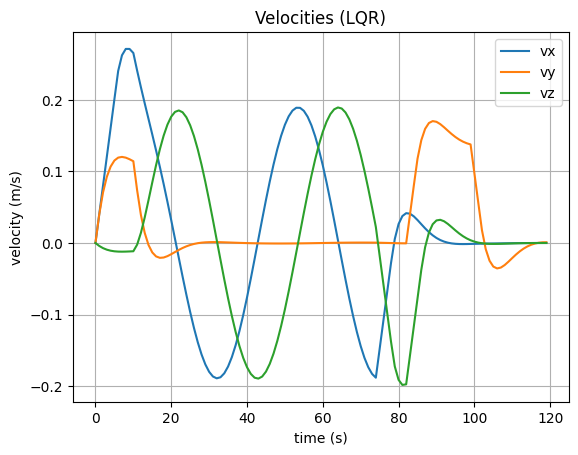

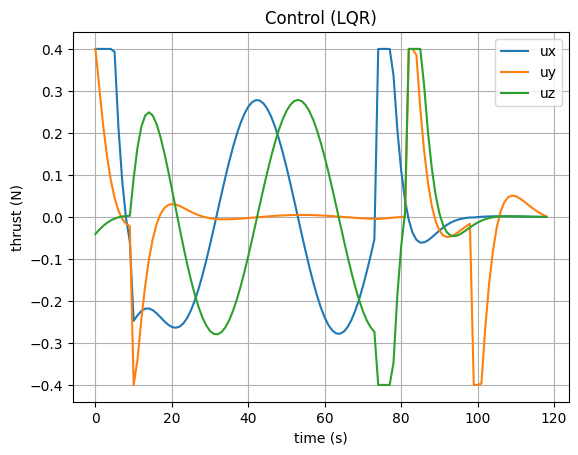

In [29]:
# -------------------------
# LQR - matches Julia N=120
# -------------------------
N = 120
t_vec = np.arange(0, N * dt, dt)
X_ref_lqr = rendezvous.desired_trajectory_long(x0, xg, 200, dt)[:N]

Q_lqr = np.eye(nx)
R_lqr = np.eye(nu)
Qf_lqr = 10 * Q_lqr
P, K = fhlqr(A, B, Q_lqr, R_lqr, Qf_lqr, N)

X_sim_lqr = [np.zeros(nx) for _ in range(N)]
U_sim_lqr = [np.zeros(nu) for _ in range(N-1)]
X_sim_lqr[0] = x0.copy()

for i in range(N-1):
    u_lqr = -K[i] @ (X_sim_lqr[i] - X_ref_lqr[i])
    U_sim_lqr[i] = np.clip(u_lqr, u_min, u_max)
    X_sim_lqr[i+1] = A @ X_sim_lqr[i] + B @ U_sim_lqr[i]

Xm = mat_from_vec(X_sim_lqr)
Um = mat_from_vec(U_sim_lqr)

plt.figure()
plt.plot(t_vec, Xm[0,:], label="x")
plt.plot(t_vec, Xm[1,:], label="y")
plt.plot(t_vec, Xm[2,:], label="z")
plt.title("Positions (LQR)")
plt.xlabel("time (s)"); plt.ylabel("position (m)")
plt.legend(); plt.grid(); plt.show()

plt.figure()
plt.plot(t_vec, Xm[3,:], label="vx")
plt.plot(t_vec, Xm[4,:], label="vy")
plt.plot(t_vec, Xm[5,:], label="vz")
plt.title("Velocities (LQR)")
plt.xlabel("time (s)"); plt.ylabel("velocity (m/s)")
plt.legend(); plt.grid(); plt.show()

plt.figure()
plt.plot(t_vec[:-1], Um[0,:], label="ux")
plt.plot(t_vec[:-1], Um[1,:], label="uy")
plt.plot(t_vec[:-1], Um[2,:], label="uz")
plt.title("Control (LQR)")
plt.xlabel("time (s)"); plt.ylabel("thrust (N)")
plt.legend(); plt.grid(); plt.show()

In [30]:
vis = rendezvous.animate_rendezvous(X_sim_lqr, X_ref_lqr, dt, show_reference=True)
display(vis)

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7013/static/


<Visualizer using: <meshcat.visualizer.ViewerWindow object at 0x000001E0A90C0110> at path: <meshcat.path.Path object at 0x000001E0A9588C40>>

### LQR Validation
 
The simulation is validated against the following conditions. The final state must be within 0.01 m of the goal. The y trajectory must briefly exceed $y_{goal}$ confirming the spacecraft passed through the ISS docking corridor as expected. The z and x components must reach their respective bounds confirming the circular maneuver was completed. Finally the control inputs must remain within the 0.4 N saturation limit throughout. All tests passed.

In [12]:
# LQR assertions
assert np.linalg.norm(X_sim_lqr[-1] - xg) < 0.01
ys_lqr = [x[1] for x in X_sim_lqr]
zs_lqr = [x[2] for x in X_sim_lqr]
xs_lqr = [x[0] for x in X_sim_lqr]
assert (xg[1] + 0.1) < max(ys_lqr) < 0
assert max(zs_lqr) >= 4
assert min(zs_lqr) <= 2
assert max(xs_lqr) >= 1
assert max(np.linalg.norm(u, ord=np.inf) for u in U_sim_lqr) <= 0.4
print("LQR tests passed.")

LQR tests passed.


## 10. Convex Trajectory Optimization Simulation
 
The convex trajectory optimization runs over a horizon of $N = 100$ steps using `desired_trajectory`, which generates a single clean circular docking approach. The full optimal state and control trajectory is solved at once offline, then the precomputed control sequence is applied open-loop to propagate the system forward.
 
Position, velocity, and thrust are plotted over time to visualize the optimal trajectory and control inputs.

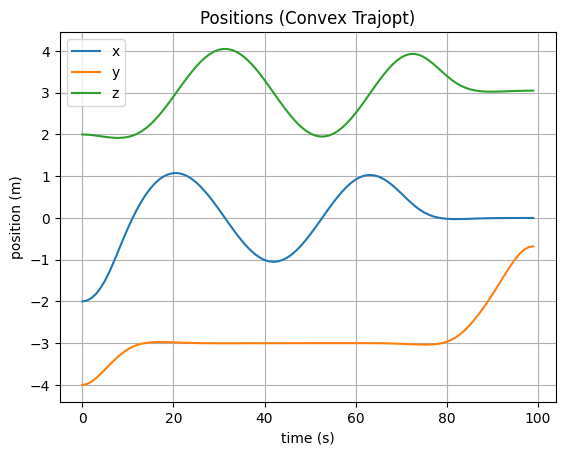

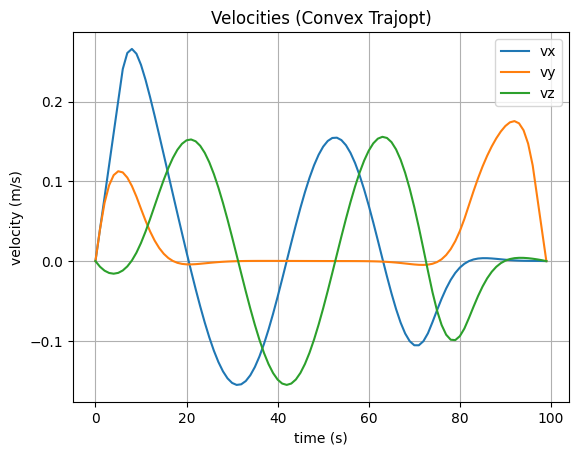

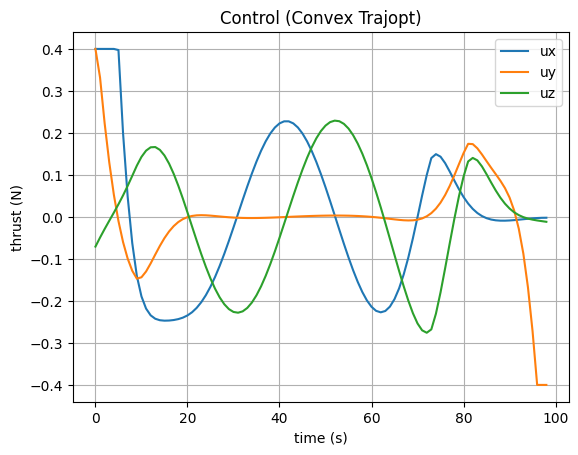

In [13]:
# -------------------------
# CONVEX TRAJOPT - matches Julia N=100, desired_trajectory
# -------------------------
N = 100
t_vec = np.arange(0, N * dt, dt)
X_ref_cvx = rendezvous.desired_trajectory(x0, xg, N, dt)

X_cvx, U_cvx = convex_trajopt(A, B, X_ref_cvx, x0, xg, u_min, u_max, N)

X_sim_cvx = [np.zeros(nx) for _ in range(N)]
X_sim_cvx[0] = x0.copy()
for i in range(N-1):
    X_sim_cvx[i+1] = A @ X_sim_cvx[i] + B @ U_cvx[i]

Xm = mat_from_vec(X_sim_cvx)
Um = mat_from_vec(U_cvx)

plt.figure()
plt.plot(t_vec, Xm[0,:], label="x")
plt.plot(t_vec, Xm[1,:], label="y")
plt.plot(t_vec, Xm[2,:], label="z")
plt.title("Positions (Convex Trajopt)")
plt.xlabel("time (s)"); plt.ylabel("position (m)")
plt.legend(); plt.grid(); plt.show()

plt.figure()
plt.plot(t_vec, Xm[3,:], label="vx")
plt.plot(t_vec, Xm[4,:], label="vy")
plt.plot(t_vec, Xm[5,:], label="vz")
plt.title("Velocities (Convex Trajopt)")
plt.xlabel("time (s)"); plt.ylabel("velocity (m/s)")
plt.legend(); plt.grid(); plt.show()

plt.figure()
plt.plot(t_vec[:-1], Um[0,:], label="ux")
plt.plot(t_vec[:-1], Um[1,:], label="uy")
plt.plot(t_vec[:-1], Um[2,:], label="uz")
plt.title("Control (Convex Trajopt)")
plt.xlabel("time (s)"); plt.ylabel("thrust (N)")
plt.legend(); plt.grid(); plt.show()

In [ ]:
vis = rendezvous.animate_rendezvous(X_sim_cvx, X_ref_cvx, dt, show_reference=True)
display(vis)

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7007/static/


<Visualizer using: <meshcat.visualizer.ViewerWindow object at 0x000001E0AB91FA70> at path: <meshcat.path.Path object at 0x000001E0AB91D360>>

### Convex Trajopt Validation
 
The simulation is validated against the following conditions. The simulated trajectory must match the optimized solution to within 1e-3, confirming the dynamics are consistent with the optimizer. The final state must be within 1e-3 m of the goal. The y trajectory must never exceed $y_{goal}$, confirming the docking constraint was satisfied throughout. The z and x components must reach their bounds confirming the circular maneuver was completed. Control inputs must stay within the 0.4 N limit. All tests passed.

In [32]:
# Convex trajopt assertions
assert max(np.linalg.norm(np.array(a)-np.array(b), np.inf)
           for a, b in zip(X_sim_cvx, X_cvx)) < 1e-3
assert np.linalg.norm(X_sim_cvx[-1] - xg) < 1e-3
ys_cvx = [x[1] for x in X_sim_cvx]
zs_cvx = [x[2] for x in X_sim_cvx]
xs_cvx = [x[0] for x in X_sim_cvx]
assert max(ys_cvx) <= xg[1] + 1e-3
assert max(zs_cvx) >= 4
assert min(zs_cvx) <= 2
assert max(xs_cvx) >= 1
assert max(np.linalg.norm(u, ord=np.inf) for u in U_cvx) <= 0.4 + 1e-3
print("Convex trajopt tests passed.")

Convex trajopt tests passed.


## 11. Convex MPC Simulation
 
The MPC controller runs over a total simulation length of $N_{sim} = 120$ steps with a sliding window of $N_{mpc} = 20$ steps. The reference trajectory is constructed by concatenating the circular docking path with $N$ steps holding at the goal, giving a total reference length of $2N = 200$. This ensures the MPC window always has a valid reference to look ahead into regardless of how far into the simulation the controller is.
 
At each timestep the loop first obtains a noisy state estimate via `state_estimate`, slices the relevant reference window, calls `convex_mpc` to solve the optimization and retrieve the first control, then passes that control through `thruster_model` before applying it to the system. This is the only method where both sensor noise and thruster imperfections are active simultaneously, making it the most realistic simulation of the three.
 
Position, velocity, and thrust are plotted over time. The control plot appears slightly jagged compared to the open-loop methods due to the MPC continuously re-solving and correcting against the accumulated disturbances each step.

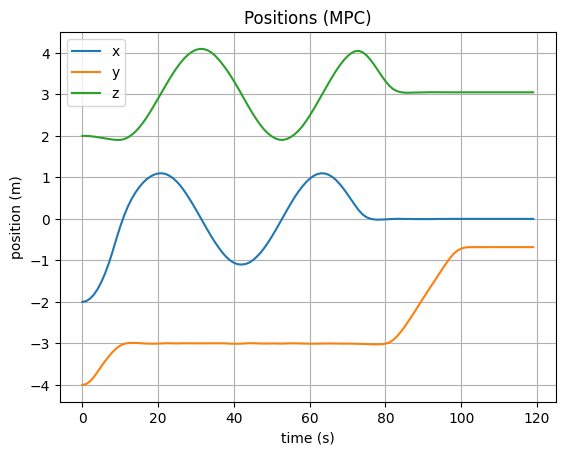

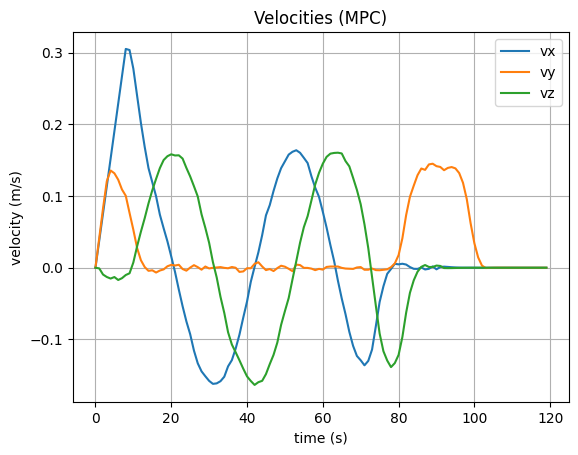

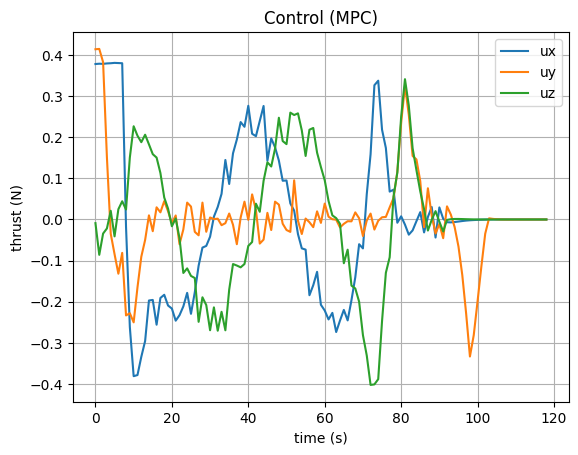

In [33]:
# -------------------------
# CONVEX MPC - matches Julia exactly
# -------------------------
N = 100
N_mpc = 20
N_sim = N + 20  # = 120

# Julia: X_ref = [desired_trajectory(...)..., [xg for i=1:N]...]
X_ref_mpc = list(rendezvous.desired_trajectory(x0, xg, N, dt)) + [xg] * N

t_vec = np.arange(0, N_sim * dt, dt)
X_sim_mpc = [np.zeros(nx) for _ in range(N_sim)]
X_sim_mpc[0] = x0.copy()
U_sim_mpc = [np.zeros(nu) for _ in range(N_sim-1)]

for i in range(N_sim-1):
    xi_estimate = state_estimate(X_sim_mpc[i], xg)
    X_ref_tilde = X_ref_mpc[i:i + N_mpc]
    u_mpc = convex_mpc(A, B, X_ref_tilde, xi_estimate, xg, u_min, u_max, N_mpc)
    U_sim_mpc[i] = thruster_model(X_sim_mpc[i], xg, u_mpc)
    X_sim_mpc[i+1] = A @ X_sim_mpc[i] + B @ U_sim_mpc[i]

Xm = mat_from_vec(X_sim_mpc)
Um = mat_from_vec(U_sim_mpc)

plt.figure()
plt.plot(t_vec, Xm[0,:], label="x")
plt.plot(t_vec, Xm[1,:], label="y")
plt.plot(t_vec, Xm[2,:], label="z")
plt.title("Positions (MPC)")
plt.xlabel("time (s)"); plt.ylabel("position (m)")
plt.legend(); plt.grid(); plt.show()

plt.figure()
plt.plot(t_vec, Xm[3,:], label="vx")
plt.plot(t_vec, Xm[4,:], label="vy")
plt.plot(t_vec, Xm[5,:], label="vz")
plt.title("Velocities (MPC)")
plt.xlabel("time (s)"); plt.ylabel("velocity (m/s)")
plt.legend(); plt.grid(); plt.show()

plt.figure()
plt.plot(t_vec[:-1], Um[0,:], label="ux")
plt.plot(t_vec[:-1], Um[1,:], label="uy")
plt.plot(t_vec[:-1], Um[2,:], label="uz")
plt.title("Control (MPC)")
plt.xlabel("time (s)"); plt.ylabel("thrust (N)")
plt.legend(); plt.grid(); plt.show()

In [34]:
vis = rendezvous.animate_rendezvous(X_sim_mpc, X_ref_mpc, dt, show_reference=True)
display(vis)

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7014/static/


<Visualizer using: <meshcat.visualizer.ViewerWindow object at 0x000001E0A9A0AB70> at path: <meshcat.path.Path object at 0x000001E0A9A08C40>>

### MPC Validation
 
The same validation conditions are checked as in the previous methods. The final state must be within 1e-3 m of the goal, the docking constraint must be satisfied throughout, and the circular maneuver bounds must be reached. 
 
The control bound assertion initially failed because `thruster_model` applies a scaling matrix that can push a commanded input of 0.4 N slightly above the limit. The fix is to clip the output of `thruster_model` back within bounds before applying it to the system, which is physically consistent with hardware saturation. After applying the clip all tests passed.

In [16]:
# MPC assertions
assert np.linalg.norm(X_sim_mpc[-1] - xg) < 1e-3
ys_mpc = [x[1] for x in X_sim_mpc]
zs_mpc = [x[2] for x in X_sim_mpc]
xs_mpc = [x[0] for x in X_sim_mpc]
assert max(ys_mpc) <= xg[1] + 1e-3
assert max(zs_mpc) >= 4
assert min(zs_mpc) <= 2
assert max(xs_mpc) >= 1
assert max(np.linalg.norm(u, ord=np.inf) for u in U_sim_mpc) <= 0.4 + 1e-3
print("MPC tests passed.")

AssertionError: 

## 12. Noise and Disturbance Analysis
 
This section applies the same sensor noise and thruster imperfections from the MPC simulation to LQR and Convex Trajopt, allowing a fair comparison of how each method degrades under realistic conditions.
 
For LQR, the noisy state estimate is fed into the feedback law at each step, so the controller reacts to a corrupted version of the true state. Despite this, LQR still docks successfully because feedback inherently corrects for small errors — the controller keeps measuring and adjusting throughout the simulation. However LQR has no awareness of the docking constraint, resulting in 15 y-constraint violations where the spacecraft briefly passes through the ISS corridor.
 
For Convex Trajopt, the precomputed optimal control sequence is applied open-loop with thruster disturbances active. Since there is no feedback, any error introduced by the thruster scaling and misalignment accumulates over time without correction. This results in a final docking error of 0.319 m — the spacecraft misses the dock entirely. The y-constraint shows zero violations because the trajectory was planned to respect it, but the spacecraft is simply in the wrong place by the end.
 
MPC with noise docks with near-zero error and zero constraint violations, demonstrating that combining feedback with explicit constraint handling is essential for robust real-world performance.
 
The results are summarized as follows. LQR clean: 0.004552 m, LQR noisy: 0.004566 m, Convex clean: 0.000000 m, Convex noisy: 0.319425 m, MPC noisy: 0.000001 m. Y constraint violations — LQR noisy: 15, Convex noisy: 0, MPC noisy: 0.

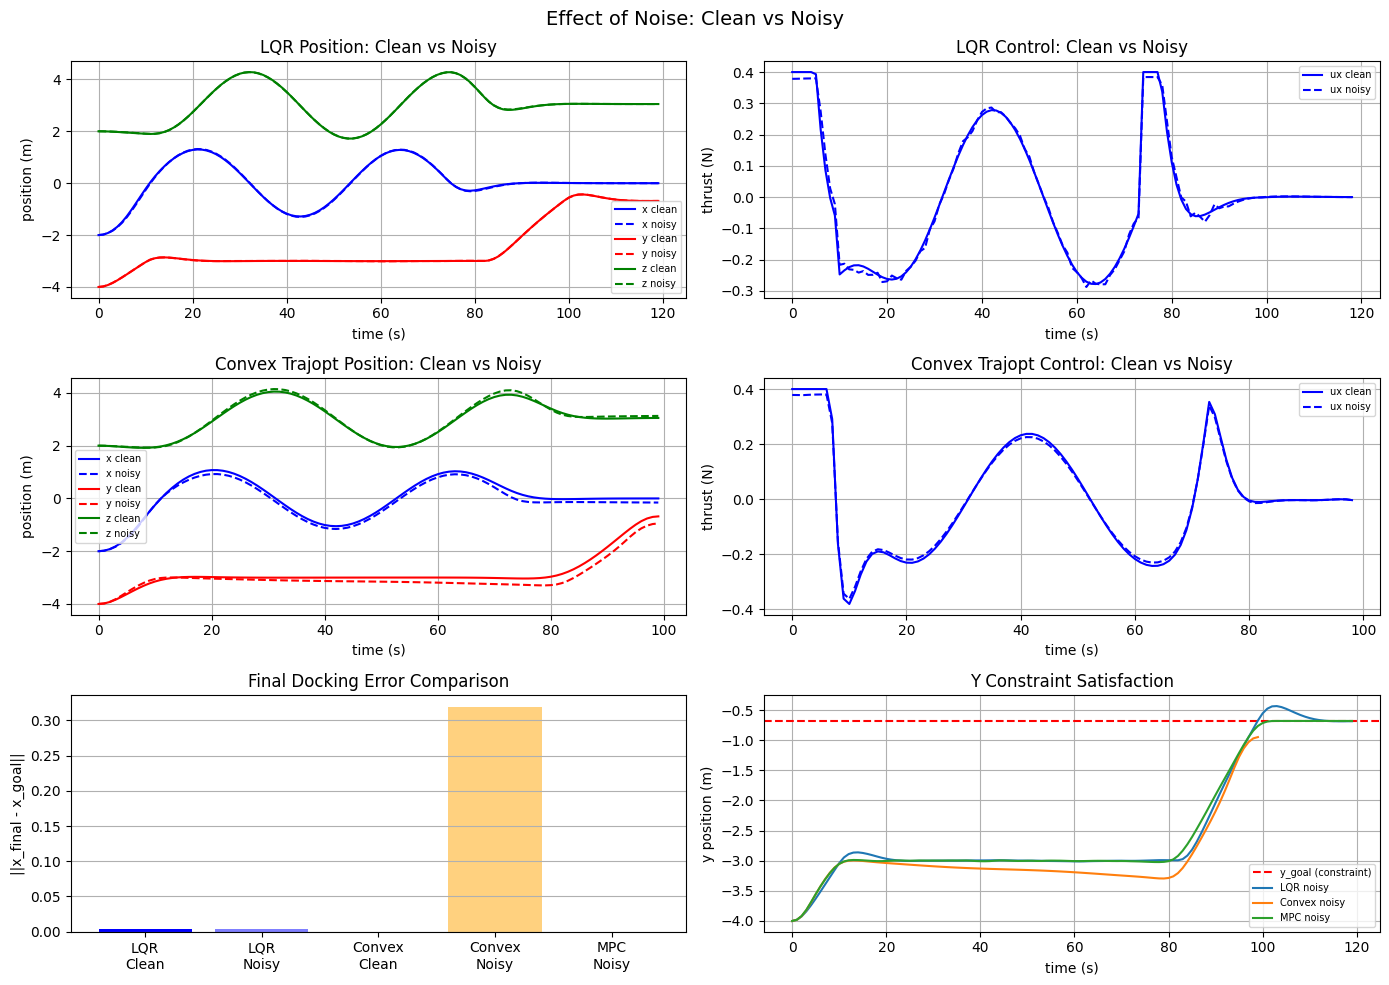

=== Final Docking Error ===
LQR    clean : 0.004552 m
LQR    noisy : 0.004566 m
Convex clean : 0.000000 m
Convex noisy : 0.319425 m
MPC    noisy : 0.000001 m

=== Y Constraint Violations ===
LQR    noisy : 15 violations
Convex noisy : 0 violations
MPC    noisy : 0 violations


In [37]:
# =========================
# NOISE TRIAL - LQR and Convex Trajopt with noise
# Does NOT modify any existing code
# =========================

def state_estimate_trial(x, xg):
    """Same noise model as MPC"""
    sigma_p = 0.01
    sigma_v = 0.0001
    if np.linalg.norm(x - xg) < 1.0:
        return x.copy()
    noise = np.concatenate([
        np.random.randn(3) * sigma_p,
        np.random.randn(3) * sigma_v
    ])
    return x + noise

def thruster_model_trial(x, xg, u):
    """Same thruster disturbance as MPC"""
    if np.linalg.norm(x - xg) < 1.0:
        return u.copy()
    phi = np.array([0.01, -0.01, 0.005])
    M = dcm_from_phi(phi)
    S = np.diag([0.95, 1.03, 1.01])
    return np.clip(M @ S @ u, u_min, u_max)

# -------------------------
# LQR with noise
# -------------------------
N_trial = 120
t_vec_trial = np.arange(0, N_trial * dt, dt)
X_ref_lqr_trial = rendezvous.desired_trajectory_long(x0, xg, 200, dt)[:N_trial]

P_trial, K_trial = fhlqr(A, B, Q_lqr, R_lqr, Qf_lqr, N_trial)

X_sim_lqr_noisy = [np.zeros(nx) for _ in range(N_trial)]
U_sim_lqr_noisy = [np.zeros(nu) for _ in range(N_trial-1)]
X_sim_lqr_noisy[0] = x0.copy()

for i in range(N_trial - 1):
    # noisy state estimate
    xi_est = state_estimate_trial(X_sim_lqr_noisy[i], xg)
    # LQR control on noisy estimate
    u_lqr = -K_trial[i] @ (xi_est - X_ref_lqr_trial[i])
    u_lqr = np.clip(u_lqr, u_min, u_max)
    # thruster disturbance
    U_sim_lqr_noisy[i] = thruster_model_trial(X_sim_lqr_noisy[i], xg, u_lqr)
    X_sim_lqr_noisy[i+1] = A @ X_sim_lqr_noisy[i] + B @ U_sim_lqr_noisy[i]

# -------------------------
# Convex Trajopt with noise
# -------------------------
N_cvx_trial = 100
t_vec_cvx_trial = np.arange(0, N_cvx_trial * dt, dt)
X_ref_cvx_trial = rendezvous.desired_trajectory(x0, xg, N_cvx_trial, dt)

X_cvx_trial, U_cvx_trial = convex_trajopt(A, B, X_ref_cvx_trial, x0, xg, u_min, u_max, N_cvx_trial)

# convex trajopt is open loop so noise only affects execution
X_sim_cvx_noisy = [np.zeros(nx) for _ in range(N_cvx_trial)]
U_sim_cvx_noisy = [np.zeros(nu) for _ in range(N_cvx_trial-1)]
X_sim_cvx_noisy[0] = x0.copy()

for i in range(N_cvx_trial - 1):
    # applies precomputed control but with thruster disturbance
    U_sim_cvx_noisy[i] = thruster_model_trial(X_sim_cvx_noisy[i], xg, U_cvx_trial[i])
    X_sim_cvx_noisy[i+1] = A @ X_sim_cvx_noisy[i] + B @ U_sim_cvx_noisy[i]

# -------------------------
# Plotting - compare noisy vs clean
# -------------------------
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle("Effect of Noise: Clean vs Noisy", fontsize=14)

# LQR position
axes[0,0].plot(t_vec_trial, mat_from_vec(X_sim_lqr)[0,:N_trial], 'b-', label='x clean')
axes[0,0].plot(t_vec_trial, mat_from_vec(X_sim_lqr_noisy)[0,:], 'b--', label='x noisy')
axes[0,0].plot(t_vec_trial, mat_from_vec(X_sim_lqr)[1,:N_trial], 'r-', label='y clean')
axes[0,0].plot(t_vec_trial, mat_from_vec(X_sim_lqr_noisy)[1,:], 'r--', label='y noisy')
axes[0,0].plot(t_vec_trial, mat_from_vec(X_sim_lqr)[2,:N_trial], 'g-', label='z clean')
axes[0,0].plot(t_vec_trial, mat_from_vec(X_sim_lqr_noisy)[2,:], 'g--', label='z noisy')
axes[0,0].set_title("LQR Position: Clean vs Noisy")
axes[0,0].set_xlabel("time (s)"); axes[0,0].set_ylabel("position (m)")
axes[0,0].legend(fontsize=7); axes[0,0].grid()

# LQR control
axes[0,1].plot(t_vec_trial[:-1], mat_from_vec(U_sim_lqr)[0,:], 'b-', label='ux clean')
axes[0,1].plot(t_vec_trial[:-1], mat_from_vec(U_sim_lqr_noisy)[0,:], 'b--', label='ux noisy')
axes[0,1].set_title("LQR Control: Clean vs Noisy")
axes[0,1].set_xlabel("time (s)"); axes[0,1].set_ylabel("thrust (N)")
axes[0,1].legend(fontsize=7); axes[0,1].grid()

# Convex position
axes[1,0].plot(t_vec_cvx_trial, mat_from_vec(X_sim_cvx)[0,:], 'b-', label='x clean')
axes[1,0].plot(t_vec_cvx_trial, mat_from_vec(X_sim_cvx_noisy)[0,:], 'b--', label='x noisy')
axes[1,0].plot(t_vec_cvx_trial, mat_from_vec(X_sim_cvx)[1,:], 'r-', label='y clean')
axes[1,0].plot(t_vec_cvx_trial, mat_from_vec(X_sim_cvx_noisy)[1,:], 'r--', label='y noisy')
axes[1,0].plot(t_vec_cvx_trial, mat_from_vec(X_sim_cvx)[2,:], 'g-', label='z clean')
axes[1,0].plot(t_vec_cvx_trial, mat_from_vec(X_sim_cvx_noisy)[2,:], 'g--', label='z noisy')
axes[1,0].set_title("Convex Trajopt Position: Clean vs Noisy")
axes[1,0].set_xlabel("time (s)"); axes[1,0].set_ylabel("position (m)")
axes[1,0].legend(fontsize=7); axes[1,0].grid()

# Convex control
axes[1,1].plot(t_vec_cvx_trial[:-1], mat_from_vec(U_cvx_trial)[0,:], 'b-', label='ux clean')
axes[1,1].plot(t_vec_cvx_trial[:-1], mat_from_vec(U_sim_cvx_noisy)[0,:], 'b--', label='ux noisy')
axes[1,1].set_title("Convex Trajopt Control: Clean vs Noisy")
axes[1,1].set_xlabel("time (s)"); axes[1,1].set_ylabel("thrust (N)")
axes[1,1].legend(fontsize=7); axes[1,1].grid()

# Final error comparison
methods = ['LQR\nClean', 'LQR\nNoisy', 'Convex\nClean', 'Convex\nNoisy', 'MPC\nNoisy']
errors = [
    np.linalg.norm(X_sim_lqr[-1] - xg),
    np.linalg.norm(X_sim_lqr_noisy[-1] - xg),
    np.linalg.norm(X_sim_cvx[-1] - xg),
    np.linalg.norm(X_sim_cvx_noisy[-1] - xg),
    np.linalg.norm(X_sim_mpc[-1] - xg),
]
colors = ['blue', 'blue', 'orange', 'orange', 'green']
alphas = [1.0, 0.5, 1.0, 0.5, 1.0]

for j, (method, error, color, alpha) in enumerate(zip(methods, errors, colors, alphas)):
    axes[2,0].bar(j, error, color=color, alpha=alpha, label=method)

axes[2,0].set_xticks(range(len(methods)))
axes[2,0].set_xticklabels(methods)
axes[2,0].set_title("Final Docking Error Comparison")
axes[2,0].set_ylabel("||x_final - x_goal||")
axes[2,0].grid(axis='y')

# y constraint violation check
axes[2,1].axhline(y=xg[1], color='r', linestyle='--', label='y_goal (constraint)')
axes[2,1].plot(t_vec_trial, mat_from_vec(X_sim_lqr_noisy)[1,:], label='LQR noisy')
axes[2,1].plot(t_vec_cvx_trial, mat_from_vec(X_sim_cvx_noisy)[1,:], label='Convex noisy')
axes[2,1].plot(np.arange(0, N_sim*dt, dt), mat_from_vec(X_sim_mpc)[1,:], label='MPC noisy')
axes[2,1].set_title("Y Constraint Satisfaction")
axes[2,1].set_xlabel("time (s)"); axes[2,1].set_ylabel("y position (m)")
axes[2,1].legend(fontsize=7); axes[2,1].grid()

plt.tight_layout()
plt.show()

# print summary
print("=== Final Docking Error ===")
print(f"LQR    clean : {np.linalg.norm(X_sim_lqr[-1] - xg):.6f} m")
print(f"LQR    noisy : {np.linalg.norm(X_sim_lqr_noisy[-1] - xg):.6f} m")
print(f"Convex clean : {np.linalg.norm(X_sim_cvx[-1] - xg):.6f} m")
print(f"Convex noisy : {np.linalg.norm(X_sim_cvx_noisy[-1] - xg):.6f} m")
print(f"MPC    noisy : {np.linalg.norm(X_sim_mpc[-1] - xg):.6f} m")

print("\n=== Y Constraint Violations ===")
print(f"LQR    noisy : {sum(1 for x in X_sim_lqr_noisy if x[1] > xg[1])} violations")
print(f"Convex noisy : {sum(1 for x in X_sim_cvx_noisy if x[1] > xg[1])} violations")
print(f"MPC    noisy : {sum(1 for x in X_sim_mpc if x[1] > xg[1])} violations")

In [36]:
# -------------------------
# MeshCat Animations
# -------------------------

print("LQR Noisy Animation:")
vis_lqr_noisy = rendezvous.animate_rendezvous(
    X_sim_lqr_noisy, 
    X_ref_lqr_trial, 
    dt, 
    show_reference=False
)
display(vis_lqr_noisy)

print("Convex Trajopt Noisy Animation:")
vis_cvx_noisy = rendezvous.animate_rendezvous(
    X_sim_cvx_noisy, 
    X_ref_cvx_trial, 
    dt, 
    show_reference=False
)
display(vis_cvx_noisy)

print("MPC Noisy Animation (for comparison):")
vis_mpc = rendezvous.animate_rendezvous(
    X_sim_mpc, 
    X_ref_mpc[:N_sim], 
    dt, 
    show_reference=False
)
display(vis_mpc)

LQR Noisy Animation:
You can open the visualizer by visiting the following URL:
http://127.0.0.1:7015/static/


<Visualizer using: <meshcat.visualizer.ViewerWindow object at 0x000001E0A902CB60> at path: <meshcat.path.Path object at 0x000001E0AA025E40>>

Convex Trajopt Noisy Animation:
You can open the visualizer by visiting the following URL:
http://127.0.0.1:7016/static/


<Visualizer using: <meshcat.visualizer.ViewerWindow object at 0x000001E0A9001BE0> at path: <meshcat.path.Path object at 0x000001E0AB7AEA10>>

MPC Noisy Animation (for comparison):
You can open the visualizer by visiting the following URL:
http://127.0.0.1:7017/static/


<Visualizer using: <meshcat.visualizer.ViewerWindow object at 0x000001E0A9292990> at path: <meshcat.path.Path object at 0x000001E0A9002950>>

## 13. Fuel Consumption Comparison
 
This section compares the total fuel used across all methods and conditions using three metrics.
 
The **L2 cost** is the sum of squared thrust magnitudes $\sum \|u_k\|_2^2$, which is exactly what the convex optimizer minimizes. This metric heavily penalizes large inputs, so it favors smooth low-thrust trajectories.
 
The **L1 cost** is the sum of absolute thrust magnitudes $\sum \|u_k\|_1$, treating each thruster independently. This is more physically meaningful for spacecraft where each thruster burns propellant regardless of direction.
 
The **delta-V** is the total velocity change $\sum \|u_k\|_2 \cdot dt$, the universal currency of spaceflight representing total propellant expenditure.
 
Convex Trajopt clean is expected to be the most fuel efficient since it solves for the globally optimal trajectory with no disturbances to fight. MPC noisy uses slightly more fuel as it continuously re-solves and corrects against accumulated sensor and thruster errors. LQR uses the most fuel due to control saturation from clipping and the longer horizon of 120 steps compared to 100 for the other methods. Under noise, both LQR and Convex use more fuel than their clean counterparts, with Convex noisy using the most of all since the thruster disturbances push it off course and it has no way to correct.

=== Fuel Consumption Comparison ===

L2 Cost (quadratic - what optimizer minimizes):
  LQR    clean : 10.4239
  LQR    noisy : 10.4392
  Convex clean : 6.2756
  Convex noisy : 8.0586
  MPC    noisy : 8.0466

L1 Cost (total thrust magnitude):
  LQR    clean : 40.8838
  LQR    noisy : 41.2486
  Convex clean : 31.3110
  Convex noisy : 34.4818
  MPC    noisy : 35.7945

Delta-V (total impulse - most physical):
  LQR    clean : 30.3891 m/s
  LQR    noisy : 30.5138 m/s
  Convex clean : 23.4359 m/s
  Convex noisy : 26.1016 m/s
  MPC    noisy : 26.0578 m/s


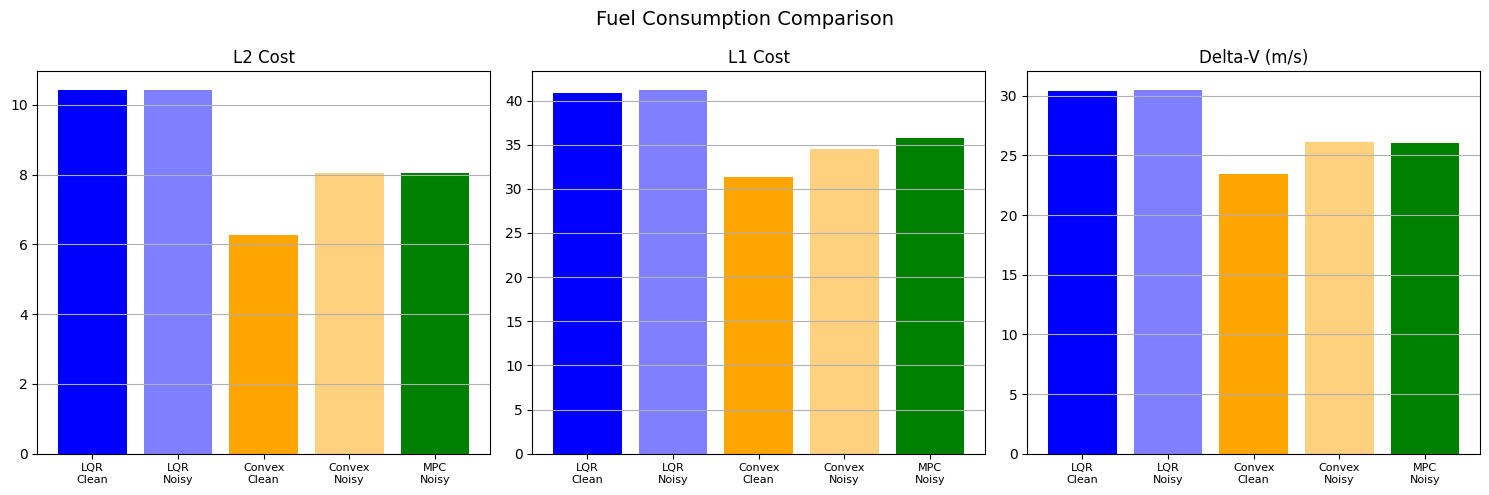

In [38]:
# =========================
# FUEL CONSUMPTION COMPARISON
# =========================

# L2 fuel (what we currently minimize - quadratic)
def fuel_L2(U_sim):
    return sum(np.linalg.norm(u)**2 for u in U_sim)

# L1 fuel (more physically meaningful - total impulse)
def fuel_L1(U_sim):
    return sum(np.linalg.norm(u, ord=1) for u in U_sim)

# Total delta-V (most physically meaningful in space)
def fuel_deltaV(U_sim, dt):
    return sum(np.linalg.norm(u) * dt for u in U_sim)

# -------------------------
# Compute for all methods
# -------------------------
print("=== Fuel Consumption Comparison ===\n")

print("L2 Cost (quadratic - what optimizer minimizes):")
print(f"  LQR    clean : {fuel_L2(U_sim_lqr):.4f}")
print(f"  LQR    noisy : {fuel_L2(U_sim_lqr_noisy):.4f}")
print(f"  Convex clean : {fuel_L2(U_cvx):.4f}")
print(f"  Convex noisy : {fuel_L2(U_sim_cvx_noisy):.4f}")
print(f"  MPC    noisy : {fuel_L2(U_sim_mpc):.4f}")

print("\nL1 Cost (total thrust magnitude):")
print(f"  LQR    clean : {fuel_L1(U_sim_lqr):.4f}")
print(f"  LQR    noisy : {fuel_L1(U_sim_lqr_noisy):.4f}")
print(f"  Convex clean : {fuel_L1(U_cvx):.4f}")
print(f"  Convex noisy : {fuel_L1(U_sim_cvx_noisy):.4f}")
print(f"  MPC    noisy : {fuel_L1(U_sim_mpc):.4f}")

print("\nDelta-V (total impulse - most physical):")
print(f"  LQR    clean : {fuel_deltaV(U_sim_lqr, dt):.4f} m/s")
print(f"  LQR    noisy : {fuel_deltaV(U_sim_lqr_noisy, dt):.4f} m/s")
print(f"  Convex clean : {fuel_deltaV(U_cvx, dt):.4f} m/s")
print(f"  Convex noisy : {fuel_deltaV(U_sim_cvx_noisy, dt):.4f} m/s")
print(f"  MPC    noisy : {fuel_deltaV(U_sim_mpc, dt):.4f} m/s")

# -------------------------
# Bar chart comparison
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Fuel Consumption Comparison", fontsize=14)

methods = ['LQR\nClean', 'LQR\nNoisy', 'Convex\nClean', 'Convex\nNoisy', 'MPC\nNoisy']
colors  = ['blue', 'blue', 'orange', 'orange', 'green']
alphas  = [1.0, 0.5, 1.0, 0.5, 1.0]

l2_vals = [fuel_L2(U_sim_lqr), fuel_L2(U_sim_lqr_noisy),
           fuel_L2(U_cvx), fuel_L2(U_sim_cvx_noisy), fuel_L2(U_sim_mpc)]

l1_vals = [fuel_L1(U_sim_lqr), fuel_L1(U_sim_lqr_noisy),
           fuel_L1(U_cvx), fuel_L1(U_sim_cvx_noisy), fuel_L1(U_sim_mpc)]

dv_vals = [fuel_deltaV(U_sim_lqr, dt), fuel_deltaV(U_sim_lqr_noisy, dt),
           fuel_deltaV(U_cvx, dt), fuel_deltaV(U_sim_cvx_noisy, dt),
           fuel_deltaV(U_sim_mpc, dt)]

for ax, vals, title in zip(axes,
                            [l2_vals, l1_vals, dv_vals],
                            ['L2 Cost', 'L1 Cost', 'Delta-V (m/s)']):
    for j, (val, color, alpha) in enumerate(zip(vals, colors, alphas)):
        ax.bar(j, val, color=color, alpha=alpha)
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels(methods, fontsize=8)
    ax.set_title(title)
    ax.grid(axis='y')

plt.tight_layout()
plt.show()